# Завдання на використання SQL в Python

1.Встановіть бібліотеку `mysql-connector-python` через pip aбо через conda.

In [1]:
!pip install mysql-connector-python

In [2]:
import mysql.connector
from mysql.connector.connection import MySQLConnection
import datetime
import pandas as pd

2.В змінній `con` створіть підключення до бази даних employees за аналогією того, як це робилось в лекції:

In [3]:
con = mysql.connector.connect(user='root', password='So40od1.',
                              host='127.0.0.1',
                              database='employees')

3.Виберіть максимальну і мінімальну дати найму співробітників використовуючи `con.cursor()`. Аби отримати результати в кінці, виконайте `cursor.fetchall()`.

In [30]:
cursor = con.cursor()

In [31]:
sql = """
SELECT MAX(hire_date), MIN(hire_date)
FROM employees
"""

In [32]:
cursor.execute(sql)
cursor.fetchall()

[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]

In [7]:
cursor.close()

True

Очікуваний результат:  
    `[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]`

4.Давайте зберемо інформацію про останню ЗП кожного співробіткника в базі. З використанням `con.cursor()` виберіть з таблиці `salaries` для кожного співробітника його номер, останню в базі даних (тобто ту, що відповідає найновішій `to_date`) ЗП, та значення `from_date`, `to_date` для цієї ЗП.

Результати запишіть у pandas DataFrame, який збережіть у змінну `res`. Як взяти з курсора назви колонок - вже наведено. На екран виведіть назви колонок в змінній `res`, розмір цього датафрейму та перші 3 записи в ньому.

УВАГА! Зверніть увагу, що ЗП може оновлюватись протягом одного дня, тобто є випадки, коли апдейт ЗП був в певний день, скажімо 2001-01-01 і потім стався ще один апдейт ЗП цьому співробітнику цього самого дня. Запит має це враховувати.
Також, теоретично ЗП може бути зменшена. Тож, брати дату з максимальною ЗП буде неправильно з точки зору бізнес логіки. Треба саме останнє історичне значення ЗП кожного співробітника.

In [8]:
cursor = con.cursor()

sql = """
SELECT emp_no, salary, from_date, to_date
FROM (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY emp_no ORDER BY to_date DESC, from_date DESC) AS rn
    FROM salaries
) s
WHERE rn = 1
ORDER BY emp_no;
"""
cursor.execute(sql)


In [61]:
field_names = [i[0] for i in cursor.description]

res = pd.DataFrame(cursor.fetchall(), columns=field_names)

display(res.columns)
display(res.shape)
display(res.head(3))


Index(['emp_no', 'salary', 'from_date', 'to_date'], dtype='object')

(0, 4)

,emp_no,salary,from_date,to_date


Очікуваний результат:

![](hw3_1.png)

5.В утвореній вибірці в змінній `res` скільки значень `to_date` рівні `9999-01-01`, а скільки - ні? Увага! Для виконання цього завдання важливо розуміти, який тип даних у значень колонки `to_date`. Зʼясуйте це, і потім напишіть фільтр для виводу потрібного результату.

In [62]:
#res.dtypes
#res['to_date'].map(type).value_counts()
res.to_date.loc[0]

KeyError: 0

In [35]:
count_9999 = (res['to_date'] == datetime.date(9999, 1, 1)).sum()
count_not_9999 = (res['to_date'] != datetime.date(9999, 1, 1)).sum()
# res['to_date'].value_counts()
display(count_9999, count_not_9999)

np.int64(240124)

np.int64(59900)

6.Виведіть візуально розподіл (гістограму) зарплат співробітників, які досі працюють в компанії, використовуючи результат попереднього завдання. Співробітниками, які досі працюють в компанії вважаємо тих, в кого to_date має значення 9999-01-01. Обовʼязково підпишіть графік і вісі.

Ці три завдання - приклад, як нам може бути зручно витягнути дані з бази певним запитом, а потім використати витягнуту вибірку у Python для подальшого аналізу.

In [56]:
still_work = res[res.to_date==datetime.date(9999, 1, 1)]
emp_count = still_work.groupby('salary')['emp_no'].count()
still_work[:3]


,emp_no,salary,from_date,to_date
0,10001,88958,2002-06-22,9999-01-01
1,10002,72527,2001-08-02,9999-01-01
2,10003,43311,2001-12-01,9999-01-01


In [58]:
import matplotlib.pyplot as plt

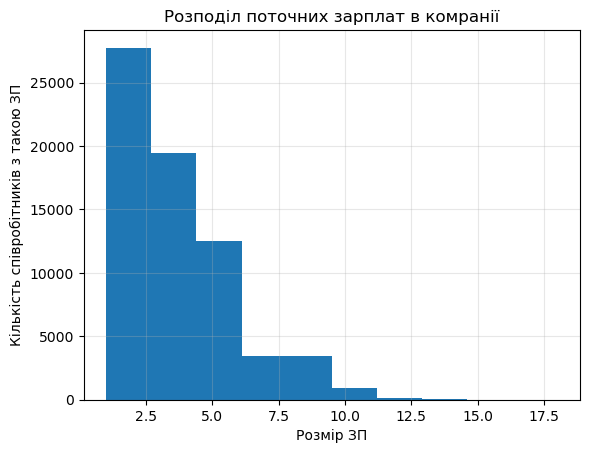

In [66]:
plt.hist(emp_count)
plt.grid(axis='both', alpha=.3)
plt.xlabel('Розмір ЗП')
plt.ylabel('Кількість співробітників з такою ЗП')
plt.title('Розподіл поточних зарплат в комранії');
plt.show();

Очікуваний результат:

![](hw3_2.png)

НЕ ЗАБУВАЄМО ЗАКРИТИ ПІДКЛЮЧЕННЯ ДО БАЗИ :)

In [67]:
con.close()